In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [2]:
# 한글 폰트 설정
matplotlib.rc("font", family="AppleGothic")
matplotlib.rc("axes", unicode_minus=False)

In [3]:
# 데이터 로드 및 결측치 처리
df = pd.read_csv("df_merged.csv", encoding="cp949")
df = df.dropna(subset=['idUser', 'ItemName', 'AgeGroup'])

print(f"전체 행: {len(df):,}")
print(f"고객수: {df['idUser'].nunique():,}")
print(f"개별상품(ItemName) 종류: {df['ItemName'].nunique():,}")
print(f"\n연령대별 고객수:")
print(df.groupby('AgeGroup')['idUser'].nunique().sort_index())
df.head()

전체 행: 854,101
고객수: 3,000
개별상품(ItemName) 종류: 3,987

연령대별 고객수:
AgeGroup
20     820
30    1280
40     477
50     291
60     132
Name: idUser, dtype: int64


,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


=== 고객당 고유 상품 수 통계 ===
count    3000.000000
mean      270.095667
std        58.406366
min        52.000000
25%       234.000000
50%       275.000000
75%       312.000000
max       441.000000
Name: ItemName, dtype: float64

=== 상품별 구매 고객 비율 분포 ===
count    3987.000000
mean        0.067744
std         0.038340
min         0.007667
25%         0.041333
50%         0.056333
75%         0.091333
max         0.164333
Name: idUser, dtype: float64

Support > 0.10 상품수: 838
Support > 0.05 상품수: 2585
Support > 0.03 상품수: 3587


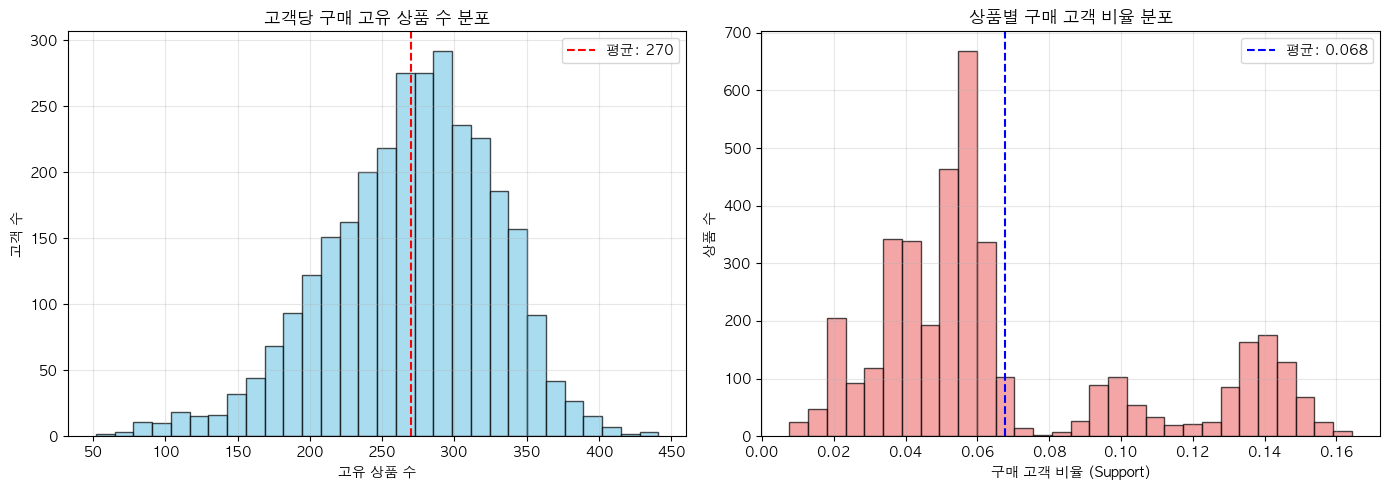

In [4]:
# 데이터 탐색: 고객당 구매 고유상품 수
products_per_customer = df.groupby('idUser')['ItemName'].nunique()

print("=== 고객당 고유 상품 수 통계 ===")
print(products_per_customer.describe())

# 상품별 구매 고객 비율 (support 분포 확인)
total_customers = df['idUser'].nunique()
item_support = df.groupby('ItemName')['idUser'].nunique() / total_customers

print(f"\n=== 상품별 구매 고객 비율 분포 ===")
print(item_support.describe())
print(f"\nSupport > 0.10 상품수: {(item_support > 0.10).sum()}")
print(f"Support > 0.05 상품수: {(item_support > 0.05).sum()}")
print(f"Support > 0.03 상품수: {(item_support > 0.03).sum()}")

# 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(products_per_customer, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('고유 상품 수')
axes[0].set_ylabel('고객 수')
axes[0].set_title('고객당 구매 고유 상품 수 분포', fontweight='bold')
axes[0].axvline(products_per_customer.mean(), color='red', linestyle='--', label=f'평균: {products_per_customer.mean():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(item_support, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('구매 고객 비율 (Support)')
axes[1].set_ylabel('상품 수')
axes[1].set_title('상품별 구매 고객 비율 분포', fontweight='bold')
axes[1].axvline(item_support.mean(), color='blue', linestyle='--', label=f'평균: {item_support.mean():.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 개별상품 기준 연관분석 (Customer-level)

In [5]:
# ============================================
# 1. 전체 고객 연관분석 (개별상품 기준)
# ============================================

# 분석 파라미터
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.3
MAX_LEN = 2

# 고객별 구매 고유상품 리스트 생성
customer_products = df.groupby('idUser')['ItemName'].apply(lambda x: list(set(x))).reset_index()
customer_products.columns = ['idUser', 'products']

print(f"총 고객수: {len(customer_products):,}")
print(f"평균 고유 구매상품수: {customer_products['products'].apply(len).mean():.1f}")
print(f"전체 상품 종류: {df['ItemName'].nunique():,}")
print(f"\n분석 파라미터: min_support={MIN_SUPPORT}, min_confidence={MIN_CONFIDENCE}, max_len={MAX_LEN}")
print(f"분석 시작...\n")

# 거래 데이터 인코딩
te = TransactionEncoder()
te_ary = te.fit(customer_products['products']).transform(customer_products['products'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"인코딩 완료: {df_encoded.shape[0]} 고객 x {df_encoded.shape[1]} 상품")

# Apriori 알고리즘
frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
print(f"빈번한 항목집합: {len(frequent_itemsets):,}개")

# 연관규칙 생성
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
    
    if len(rules) > 0:
        rules = rules.sort_values('lift', ascending=False)
        
        # 중복 제거 (A->B, B->A 중 Lift 높은 것만 유지)
        rules['상품A_temp'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['상품B_temp'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
        rules['pair_key'] = rules.apply(
            lambda r: tuple(sorted([r['상품A_temp'], r['상품B_temp']])), axis=1
        )
        rules = rules.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        rules = rules.drop(columns=['상품A_temp', '상품B_temp', 'pair_key'])
        
        print(f"\n" + "=" * 110)
        print("【전체 고객 연관분석 결과 (개별상품 기준)】")
        print("=" * 110)
        print(f"\n전체 규칙: {len(rules):,}개 (중복 제거 완료)")
        print(f"\n[상위 15개 규칙 - Lift 순]\n")
        
        display_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
        display_rules['상품A'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        display_rules['상품B'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
        result_df = display_rules[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
        result_df.index = result_df.index + 1
        result_df.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
        print(result_df.to_string())
        
        print("\n[지표 설명]")
        print("- Support: 두 상품을 모두 구매한 고객 비율")
        print("- Confidence: 상품A 구매 고객 중 상품B도 구매한 비율")
        print("- Lift: 1보다 크면 양의 연관성 (독립 대비 몇 배 더 함께 구매되는지)")
    else:
        print("조건을 만족하는 규칙이 없습니다. min_confidence를 낮춰보세요.")
        rules = pd.DataFrame()
else:
    print("조건을 만족하는 항목집합이 없습니다. min_support를 낮춰보세요.")
    rules = pd.DataFrame()

총 고객수: 3,000
평균 고유 구매상품수: 270.1
전체 상품 종류: 3,987

분석 파라미터: min_support=0.02, min_confidence=0.3, max_len=2
분석 시작...

인코딩 완료: 3000 고객 x 3987 상품
빈번한 항목집합: 149,343개
조건을 만족하는 규칙이 없습니다. min_confidence를 낮춰보세요.


In [6]:
# 전체 고객 연관분석 시각화
if len(rules) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Lift 상위 10개
    top_rules = rules.head(10)
    ax = axes[0, 0]
    labels = []
    for x, y in zip(top_rules['antecedents'], top_rules['consequents']):
        ant = ', '.join(list(x))
        cons = ', '.join(list(y))
        if len(ant) > 20: ant = ant[:20] + '...'
        if len(cons) > 20: cons = cons[:20] + '...'
        labels.append(f"{ant}\n→ {cons}")
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_rules)))
    ax.barh(range(len(top_rules)), top_rules['lift'].values, color=colors)
    ax.set_yticks(range(len(top_rules)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Lift')
    ax.set_title('상위 10개 규칙 - Lift 값', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # 2. Support vs Confidence 산점도
    ax = axes[0, 1]
    scatter = ax.scatter(rules['support'], rules['confidence'],
                        c=rules['lift'], cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.3)
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title('Support vs Confidence (색상: Lift)', fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.grid(alpha=0.3)
    
    # 3. Confidence 분포
    ax = axes[1, 0]
    ax.hist(rules['confidence'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('빈도')
    ax.set_title('신뢰도(Confidence) 분포', fontweight='bold')
    ax.axvline(rules['confidence'].mean(), color='red', linestyle='--', linewidth=2,
              label=f'평균: {rules["confidence"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Lift 분포
    ax = axes[1, 1]
    ax.hist(rules['lift'], bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
    ax.set_xlabel('Lift')
    ax.set_ylabel('빈도')
    ax.set_title('상승도(Lift) 분포', fontweight='bold')
    ax.axvline(rules['lift'].mean(), color='blue', linestyle='--', linewidth=2,
              label=f'평균: {rules["lift"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('customer_association_individual.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n시각화 저장: customer_association_individual.png")
else:
    print("규칙이 충분하지 않아 시각화를 생성할 수 없습니다.")

규칙이 충분하지 않아 시각화를 생성할 수 없습니다.


In [7]:
# ============================================
# 2. 연령대별 연관분석 (개별상품 기준)
# ============================================

# 연령대별 파라미터 (소규모 그룹 대응)
AGE_MIN_SUPPORT = 0.03
AGE_MIN_CONFIDENCE = 0.3
AGE_MAX_LEN = 2

age_groups = sorted(df['AgeGroup'].unique())
age_group_results = {}

print("=" * 110)
print("【연령대별 연관분석 결과 (개별상품 기준)】")
print("=" * 110)

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    n_customers = age_df['idUser'].nunique()
    
    # 고객별 구매 고유상품 리스트
    age_products = age_df.groupby('idUser')['ItemName'].apply(lambda x: list(set(x))).reset_index()
    age_products.columns = ['idUser', 'products']
    
    # 인코딩
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    # Apriori
    frequent_age = apriori(df_age_encoded, min_support=AGE_MIN_SUPPORT, use_colnames=True, max_len=AGE_MAX_LEN)
    
    if len(frequent_age) > 0:
        rules_age = association_rules(frequent_age, metric="confidence", min_threshold=AGE_MIN_CONFIDENCE)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            # 중복 제거
            rules_age['상품A'] = rules_age['antecedents'].apply(lambda x: ', '.join(list(x)))
            rules_age['상품B'] = rules_age['consequents'].apply(lambda x: ', '.join(list(x)))
            rules_age['pair_key'] = rules_age.apply(
                lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
            )
            rules_age = rules_age.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
            rules_age = rules_age.drop(columns=['pair_key'])
            
            age_group_results[age_group] = rules_age
            
            print(f"\n【{age_group}대】({len(age_df):,}건 거래, {n_customers:,}명 고객)")
            print(f"  규칙 수: {len(rules_age):,}개 (중복 제거 완료)")
            print(f"  평균 Lift: {rules_age['lift'].mean():.4f} | 최대 Lift: {rules_age['lift'].max():.4f}")
            
            # 상위 5개 출력
            top5 = rules_age[['상품A', '상품B', 'support', 'confidence', 'lift']].head(5).reset_index(drop=True)
            top5.index = top5.index + 1
            top5.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
            print(top5.to_string())
        else:
            print(f"\n【{age_group}대】- 조건을 만족하는 규칙 없음")
    else:
        print(f"\n【{age_group}대】- 빈번한 항목집합 없음")

print(f"\n{'=' * 110}")

【연령대별 연관분석 결과 (개별상품 기준)】

【20대】(233,828건 거래, 820명 고객)
  규칙 수: 23개 (중복 제거 완료)
  평균 Lift: 1.9793 | 최대 Lift: 2.2008
                            상품 A                                 상품 B   Support  Confidence      Lift
1      [농협청과33번] 호박고구마 10kg 왕특/대  양파 대파 감자 마늘 생강 조개 과일망 메시 메쉬 그물망 일자형  0.030488    0.308642  2.200751
2             [선진포크]앞다리 불고기 600g              산지직송 대추방울토마토 / 5kg(4번과)  0.030488    0.304878  2.192982
3  산들팜풋고추 롱그린맛고추(아삭이)(오이맛) 특품5kg                        우리가락 인큐애호박 1개  0.030488    0.304878  2.155172
4      싱싱상회 산지직송 대추방울토마토 1kg 2kg         국내산 생도라지 깐도라지  채도라지 통도라지 1Kg  0.037805    0.319588  2.148048
5                 부산생물고등어 2마리(중)                   [피쉬셀]제주갈치살 250g 냉동  0.031707    0.329114  2.141853

【30대】- 조건을 만족하는 규칙 없음

【40대】(137,632건 거래, 477명 고객)
  규칙 수: 954개 (중복 제거 완료)
  평균 Lift: 1.9516 | 최대 Lift: 3.3372
                                   상품 A                                         상품 B   Support  Confidence      Lift
1                     [사조대림] 스모크치킨 180g       

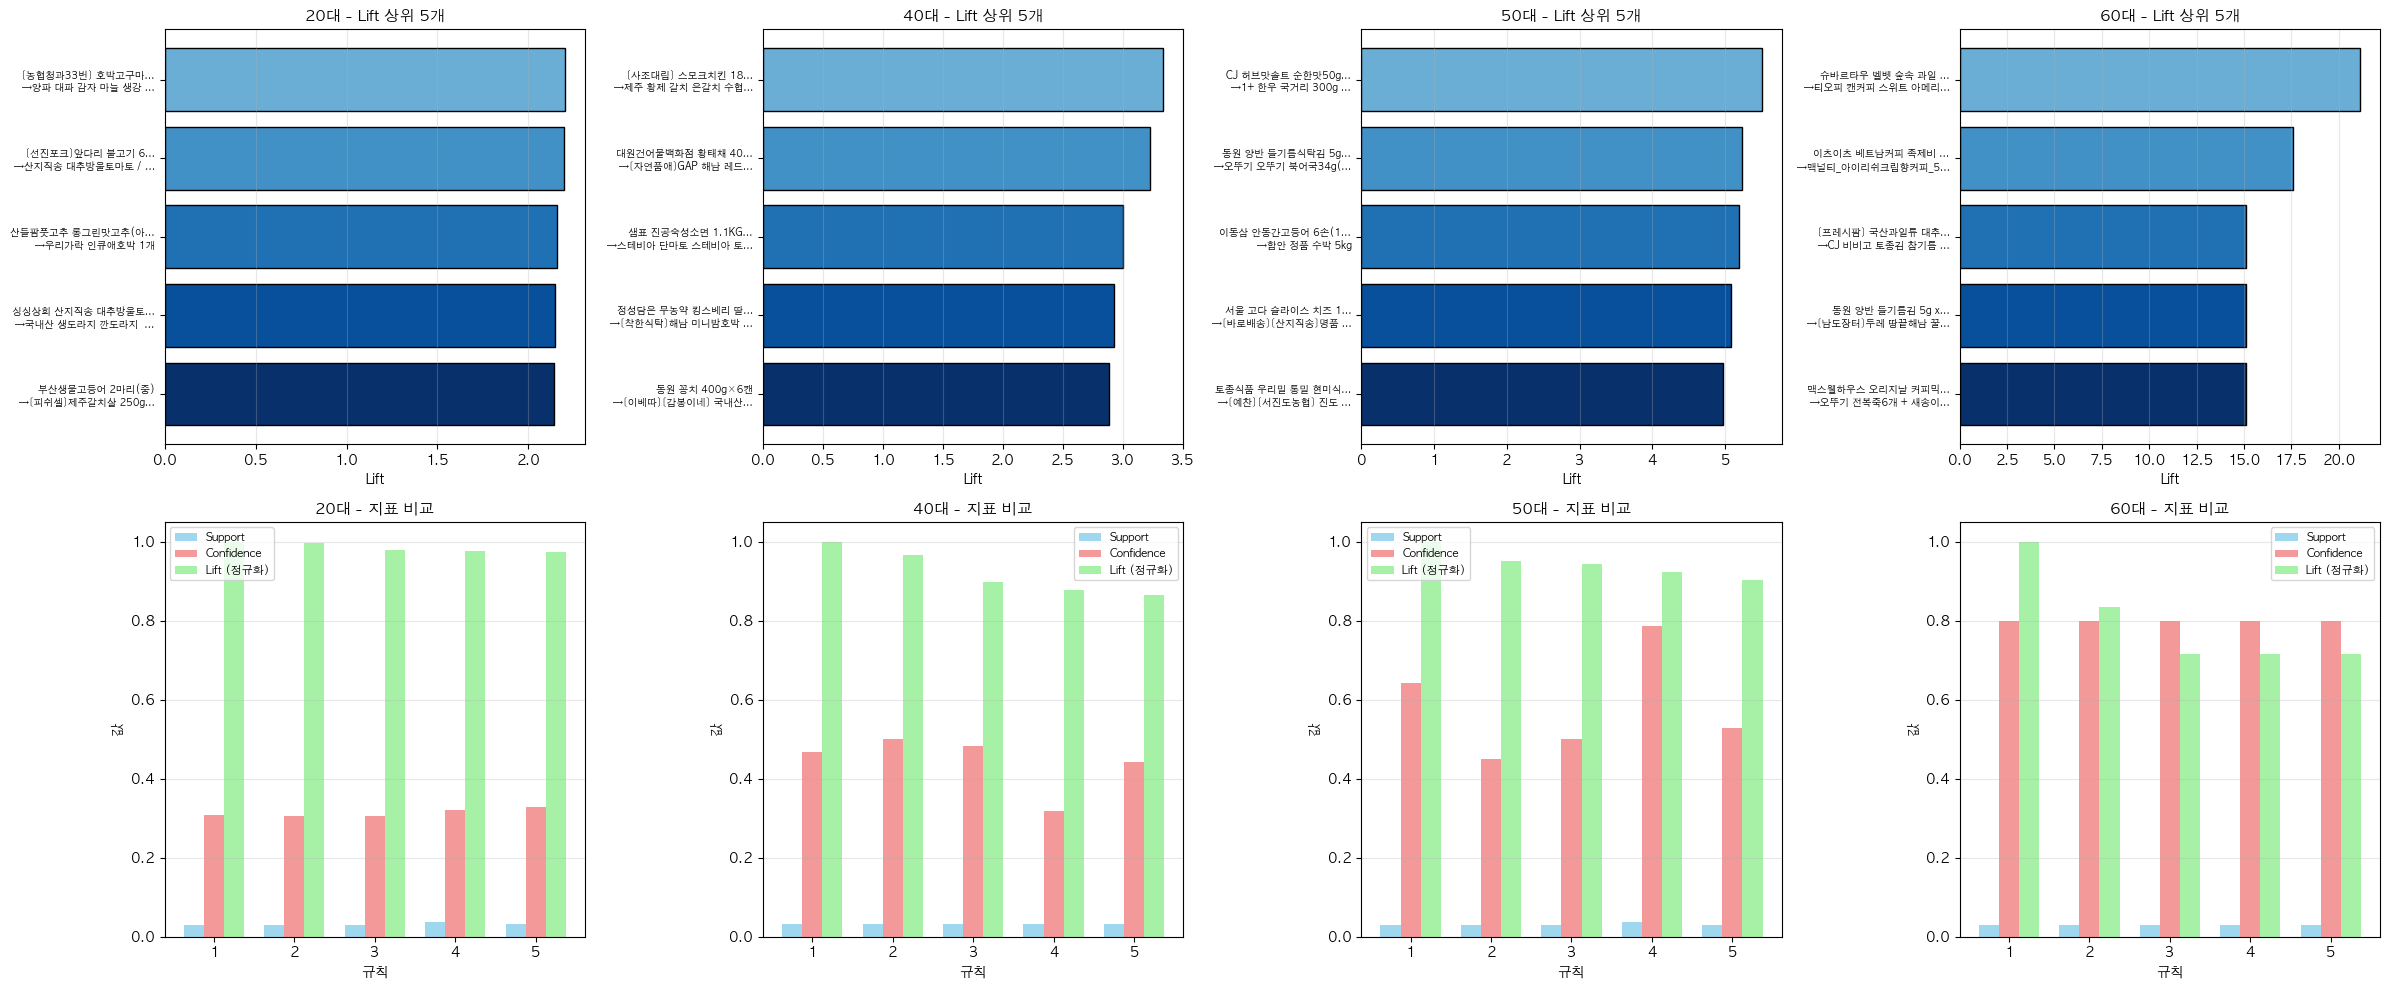


시각화 저장: age_group_association_individual.png


In [8]:
# 연령대별 연관분석 시각화
if age_group_results:
    num_groups = len(age_group_results)
    fig, axes = plt.subplots(2, num_groups, figsize=(6 * num_groups, 10))
    
    if num_groups == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (age_group, rules_age) in enumerate(age_group_results.items()):
        if len(rules_age) > 0:
            top5 = rules_age.head(5)
            
            # 1행: Lift 상위 5개
            ax = axes[0, idx]
            labels = []
            for x, y in zip(top5['antecedents'], top5['consequents']):
                ant = ', '.join(list(x))
                cons = ', '.join(list(y))
                if len(ant) > 15: ant = ant[:15] + '...'
                if len(cons) > 15: cons = cons[:15] + '...'
                labels.append(f"{ant}\n→{cons}")
            
            colors = plt.cm.Blues(np.linspace(0.5, 1, len(top5)))
            ax.barh(range(len(top5)), top5['lift'].values, color=colors, edgecolor='black')
            ax.set_yticks(range(len(top5)))
            ax.set_yticklabels(labels, fontsize=7)
            ax.set_xlabel('Lift')
            ax.set_title(f'{age_group}대 - Lift 상위 5개', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(alpha=0.3, axis='x')
            
            # 2행: Support, Confidence, Lift 비교
            ax = axes[1, idx]
            x_pos = np.arange(len(top5))
            width = 0.25
            
            ax.bar(x_pos - width, top5['support'].values, width, label='Support', alpha=0.8, color='skyblue')
            ax.bar(x_pos, top5['confidence'].values, width, label='Confidence', alpha=0.8, color='lightcoral')
            lift_max = rules_age['lift'].max()
            normalized_lift = top5['lift'].values / lift_max if lift_max > 0 else top5['lift'].values
            ax.bar(x_pos + width, normalized_lift, width, label='Lift (정규화)', alpha=0.8, color='lightgreen')
            
            ax.set_xlabel('규칙')
            ax.set_ylabel('값')
            ax.set_title(f'{age_group}대 - 지표 비교', fontsize=11, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(range(1, len(top5) + 1))
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('age_group_association_individual.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n시각화 저장: age_group_association_individual.png")
else:
    print("연령대별 규칙이 없어 시각화를 생성할 수 없습니다.")

【연령대별 비교 분석】

[연령대별 주요 지표]

연령대  고객수   거래건수   규칙수  평균Support  평균Confidence   평균Lift    최대Lift     평균구매상품
20대  820 233828    23   0.036373      0.312736 1.979302  2.200751 270.474390
40대  477 137632   954   0.037386      0.322268 1.951633  3.337220 273.691824
50대  291  83760  7058   0.036999      0.342729 2.150237  5.502101 272.807560
60대  132  36673 66700   0.035807      0.403288 2.747762 21.120000 263.477273


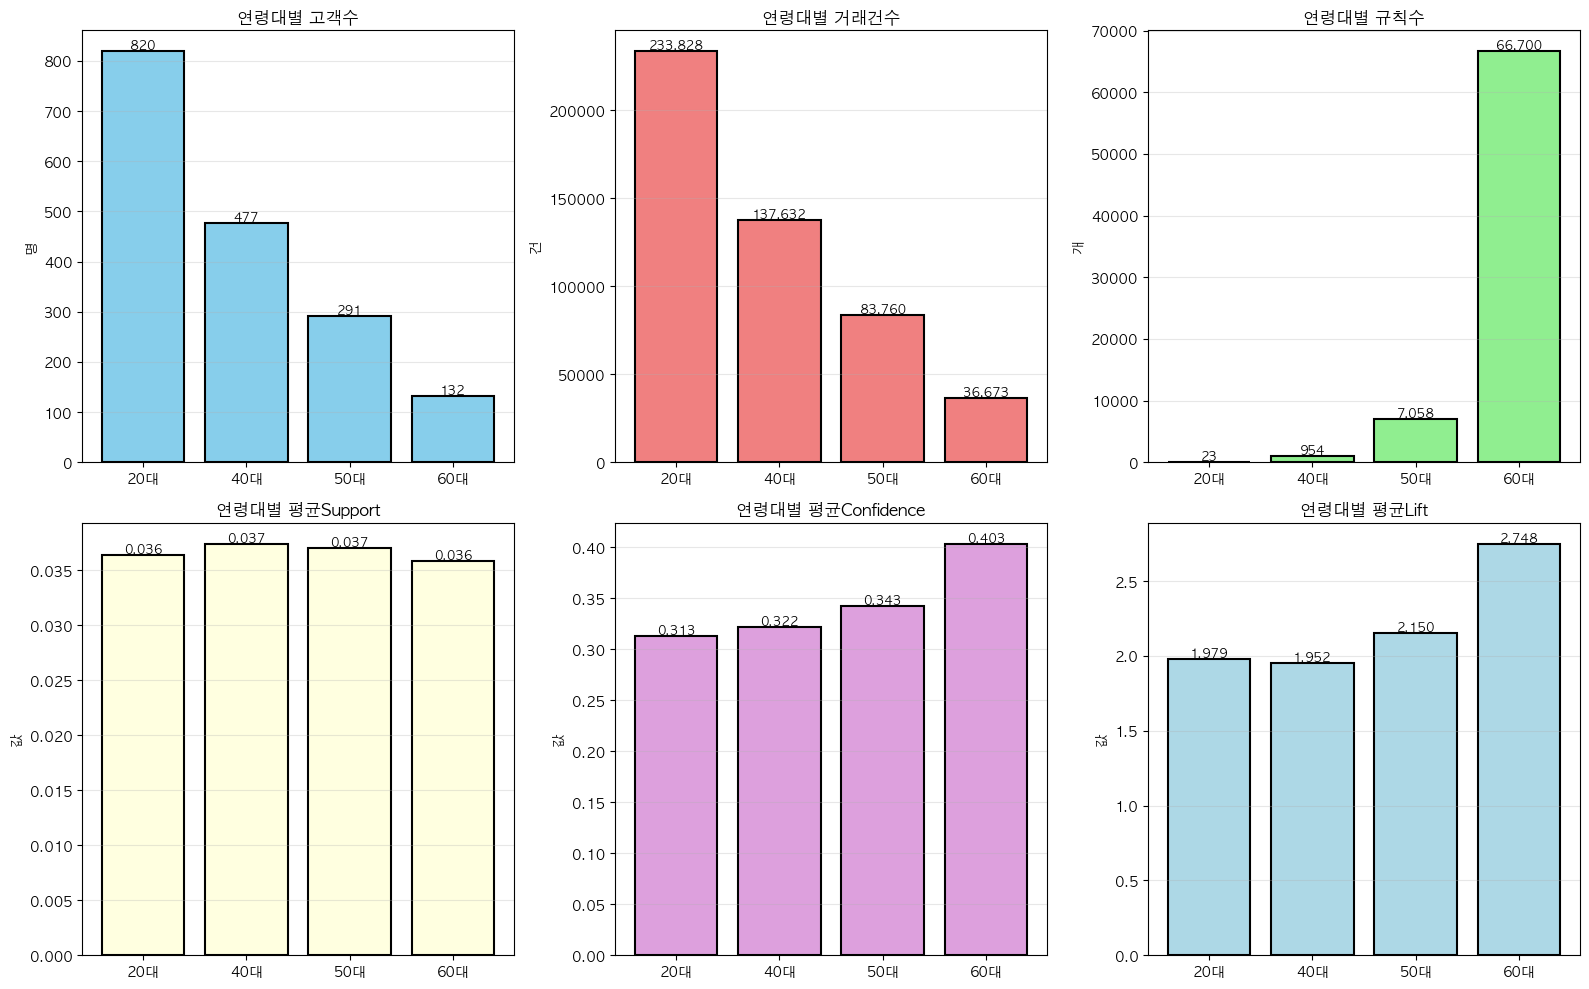


시각화 저장: age_group_comparison_individual.png


In [9]:
# ============================================
# 3. 연령대별 비교 분석
# ============================================

print("=" * 110)
print("【연령대별 비교 분석】")
print("=" * 110)

age_comparison = []

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        age_comparison.append({
            '연령대': f'{age_group}대',
            '고객수': age_df['idUser'].nunique(),
            '거래건수': len(age_df),
            '규칙수': len(rules_age),
            '평균Support': rules_age['support'].mean(),
            '평균Confidence': rules_age['confidence'].mean(),
            '평균Lift': rules_age['lift'].mean(),
            '최대Lift': rules_age['lift'].max(),
            '평균구매상품': age_df.groupby('idUser')['ItemName'].nunique().mean()
        })

comparison_df = pd.DataFrame(age_comparison)
print("\n[연령대별 주요 지표]\n")
print(comparison_df.to_string(index=False))

# 시각화
if len(comparison_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    metrics = [
        ('고객수', '명', 'skyblue'),
        ('거래건수', '건', 'lightcoral'),
        ('규칙수', '개', 'lightgreen'),
        ('평균Support', '값', 'lightyellow'),
        ('평균Confidence', '값', 'plum'),
        ('평균Lift', '값', 'lightblue')
    ]
    
    for i, (col, ylabel, color) in enumerate(metrics):
        ax = axes[i // 3, i % 3]
        ax.bar(comparison_df['연령대'], comparison_df[col], color=color, edgecolor='black', linewidth=1.5)
        ax.set_ylabel(ylabel)
        ax.set_title(f'연령대별 {col}', fontweight='bold')
        ax.grid(alpha=0.3, axis='y')
        for j, v in enumerate(comparison_df[col]):
            fmt = f'{v:.3f}' if isinstance(v, float) and v < 10 else f'{int(v):,}'
            ax.text(j, v, fmt, ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('age_group_comparison_individual.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n시각화 저장: age_group_comparison_individual.png")

In [10]:
# ============================================
# 4. 주요 인사이트 및 분석 요약
# ============================================

print("=" * 110)
print("【주요 인사이트 및 분석 요약】")
print("=" * 110)

if len(rules) > 0:
    print("\n[전체 고객 연관분석 요약]")
    print(f"  - 발견된 규칙 수 (중복 제거): {len(rules):,}개")
    print(f"  - 평균 Support: {rules['support'].mean():.4f}")
    print(f"  - 평균 Confidence: {rules['confidence'].mean():.4f}")
    print(f"  - 평균 Lift: {rules['lift'].mean():.4f}")
    print(f"  - 최고 Lift: {rules['lift'].max():.4f}")
    
    # 가장 강력한 규칙
    strongest = rules.loc[rules['lift'].idxmax()]
    ant_name = ', '.join(list(strongest['antecedents']))
    cons_name = ', '.join(list(strongest['consequents']))
    print(f"\n[가장 강력한 연관규칙]")
    print(f"  - {ant_name} → {cons_name}")
    print(f"  - Lift {strongest['lift']:.4f}: 독립적일 때보다 {strongest['lift']:.2f}배 더 함께 구매")
    print(f"  - Confidence: {strongest['confidence']:.1%}")
    print(f"  - Support: {strongest['support']:.4f}")
    
    # 가장 많이 등장하는 상품
    ant_list, cons_list = [], []
    for ant in rules['antecedents']:
        ant_list.extend(list(ant))
    for cons in rules['consequents']:
        cons_list.extend(list(cons))
    
    ant_counter = Counter(ant_list)
    cons_counter = Counter(cons_list)
    
    print(f"\n[자주 선행상품으로 나타나는 상품 TOP 5]")
    for rank, (product, count) in enumerate(ant_counter.most_common(5), 1):
        name = product if len(product) <= 40 else product[:40] + '...'
        print(f"  {rank}. {name}: {count}회")
    
    print(f"\n[자주 결과상품으로 나타나는 상품 TOP 5]")
    for rank, (product, count) in enumerate(cons_counter.most_common(5), 1):
        name = product if len(product) <= 40 else product[:40] + '...'
        print(f"  {rank}. {name}: {count}회")

# 연령대별 특징
if len(comparison_df) > 0:
    print(f"\n[연령대별 특징]")
    print(f"  - 가장 많은 고객: {comparison_df.loc[comparison_df['고객수'].idxmax(), '연령대']} ({int(comparison_df['고객수'].max()):,}명)")
    print(f"  - 가장 많은 규칙: {comparison_df.loc[comparison_df['규칙수'].idxmax(), '연령대']} ({int(comparison_df['규칙수'].max()):,}개)")
    print(f"  - 최고 평균 Lift: {comparison_df.loc[comparison_df['평균Lift'].idxmax(), '연령대']} ({comparison_df['평균Lift'].max():.4f})")
    print(f"  - 최고 평균 Confidence: {comparison_df.loc[comparison_df['평균Confidence'].idxmax(), '연령대']} ({comparison_df['평균Confidence'].max():.4f})")

print(f"\n{'=' * 110}")
print("분석 완료")
print("=" * 110)

【주요 인사이트 및 분석 요약】

[연령대별 특징]
  - 가장 많은 고객: 20대 (820명)
  - 가장 많은 규칙: 60대 (66,700개)
  - 최고 평균 Lift: 60대 (2.7478)
  - 최고 평균 Confidence: 60대 (0.4033)

분석 완료


In [11]:
# ============================================
# 5. 연령대별 연관상품 TOP 10 (중복 제거 완료)
# ============================================

print("=" * 130)
print("【연령대별 연관상품 TOP 10】(개별상품 기준, 중복 제거)")
print("=" * 130)

for age_group in age_groups:
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        if len(rules_age) > 0:
            top_10 = rules_age.head(10).copy()
            
            print(f"\n【{age_group}대】유니크 규칙 {len(rules_age):,}개 중 상위 10개")
            print("-" * 130)
            
            result_table = top_10[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
            
            result_table['Support'] = result_table['Support'].apply(lambda x: f'{x:.4f}')
            result_table['Confidence'] = result_table['Confidence'].apply(lambda x: f'{x:.1%}')
            result_table['Lift'] = result_table['Lift'].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()
        else:
            print(f"\n【{age_group}대】규칙이 없습니다.\n")

print("=" * 130)

【연령대별 연관상품 TOP 10】(개별상품 기준, 중복 제거)

【20대】유니크 규칙 23개 중 상위 10개
----------------------------------------------------------------------------------------------------------------------------------
                                상품 A                                             상품 B Support Confidence    Lift
1          [농협청과33번] 호박고구마 10kg 왕특/대              양파 대파 감자 마늘 생강 조개 과일망 메시 메쉬 그물망 일자형  0.0305      30.9%  2.2008
2                 [선진포크]앞다리 불고기 600g                          산지직송 대추방울토마토 / 5kg(4번과)  0.0305      30.5%  2.1930
3      산들팜풋고추 롱그린맛고추(아삭이)(오이맛) 특품5kg                                    우리가락 인큐애호박 1개  0.0305      30.5%  2.1552
4          싱싱상회 산지직송 대추방울토마토 1kg 2kg                     국내산 생도라지 깐도라지  채도라지 통도라지 1Kg  0.0378      32.0%  2.1480
5                     부산생물고등어 2마리(중)                               [피쉬셀]제주갈치살 250g 냉동  0.0317      32.9%  2.1419
6    국내산 고등어 15팩 / 팩당 70-100g /냉동비축품  해미래 [K쇼핑][해미래] 국내산 손질 냉동 오징어 270g 내외 (2마리) x 2팩  0.0378      32.6%  2.0743
7   [우리가락 ] [새벽배송